## SHAP ANALYSIS

we are trying to explain our model

In [2]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import joblib

df=pd.read_csv("/home/student/Projects/Startup-outcome-intelligence/data/processed/startup_data_final.csv")

/home/student/UDSC-502-14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading the Model

In [3]:
artifacts=joblib.load("../models/lgbm_model.joblib")

lgbm=artifacts["model"]
threshold=artifacts["threshold"]

## Splitting

In [4]:
x=df.drop(columns=["label"])
y=df["label"]

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

## SHAP work

In [5]:
explainer=shap.TreeExplainer(lgbm)
sv=explainer(x_test)

vals=sv.values
fail_vals=-vals # cse we trained on -ves , and want to see if we get negatives right

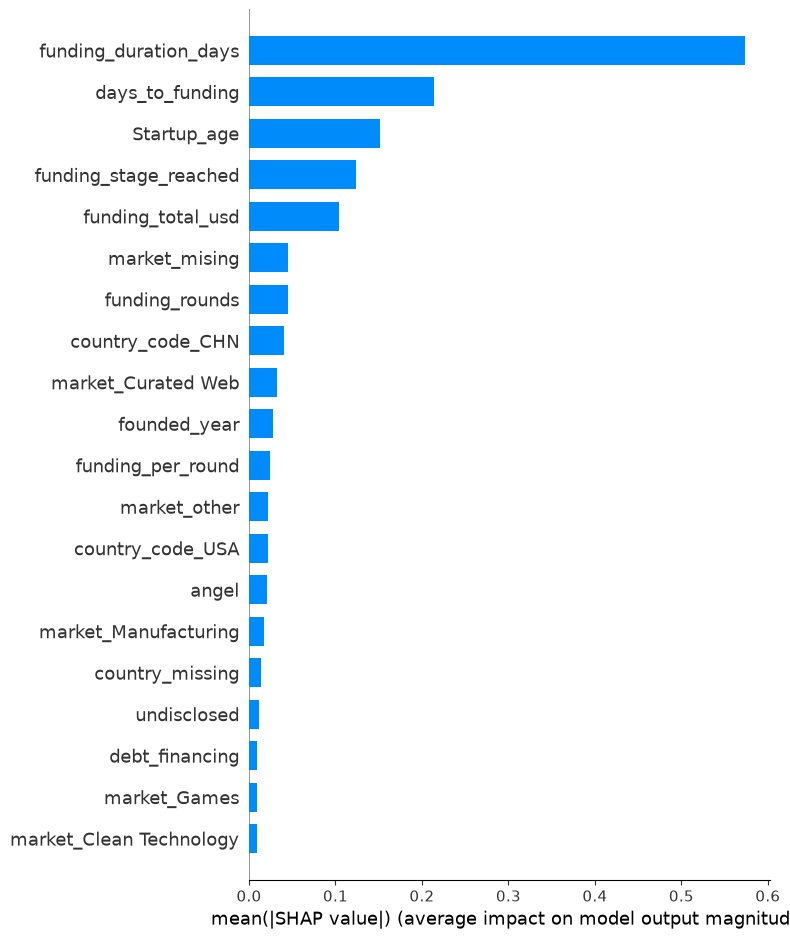

In [6]:
shap.summary_plot(fail_vals,x_test,plot_type="bar") #global feature importance

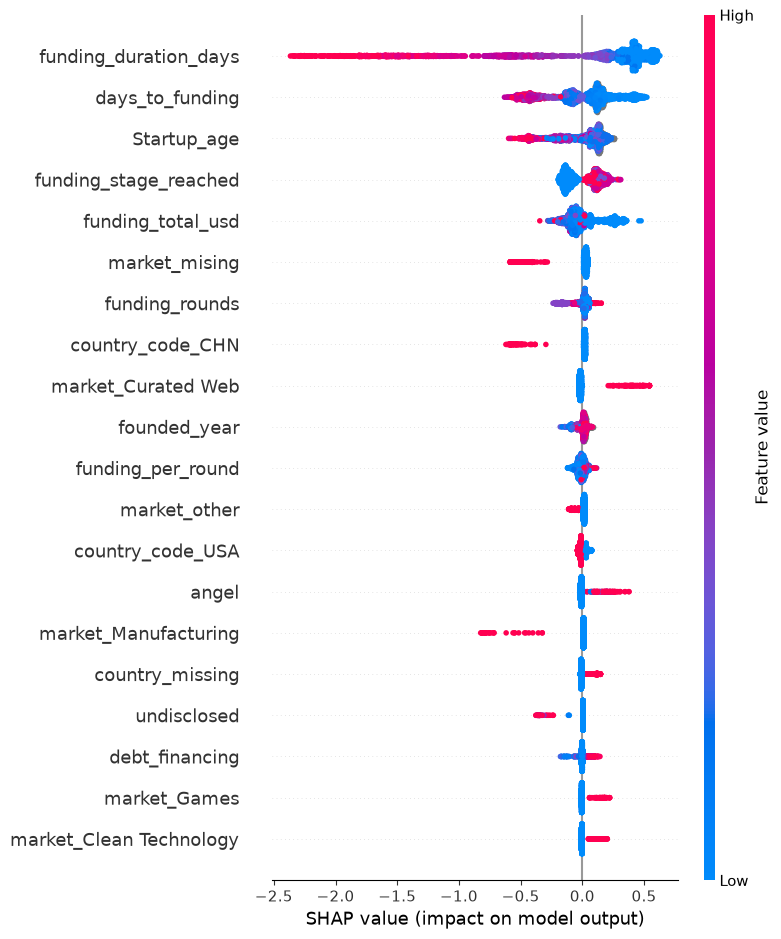

In [7]:
shap.summary_plot(fail_vals, x_test)

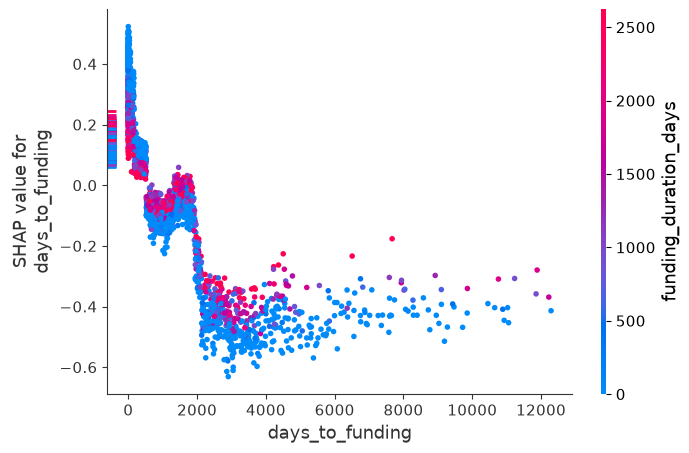

In [8]:
shap.dependence_plot("days_to_funding", fail_vals, x_test)

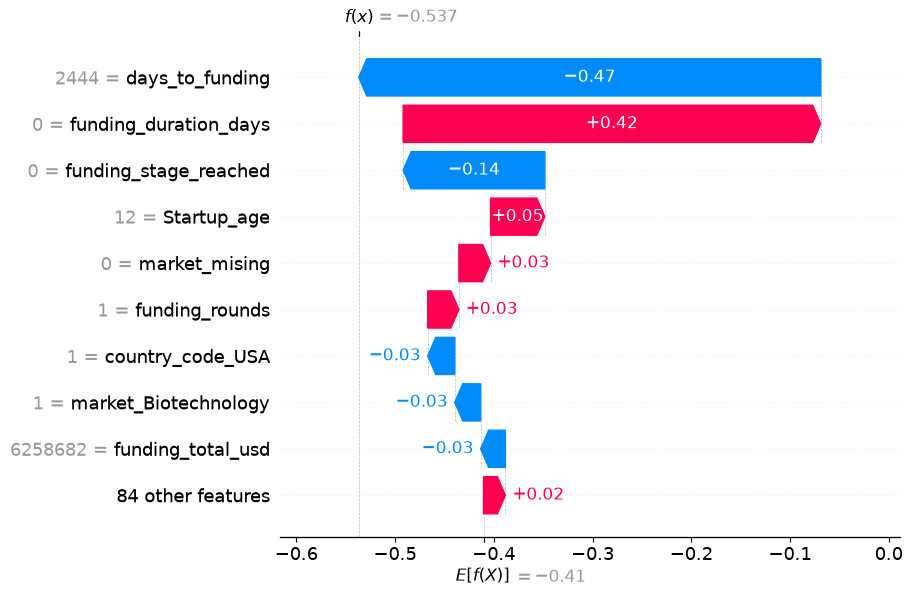

In [8]:
exp_fail = shap.Explanation(
    values=fail_vals,
    base_values=-sv.base_values,
    data=x_test.values,
    feature_names=list(x_test.columns),
)

idx=0
shap.plots.waterfall(exp_fail[idx])

### Audit: `funding_duration_days`

SHAP showed that `funding_duration_days` is the dominant feature (mean |SHAP| ≈ 0.57, about 2.7x the next feature). Long durations strongly push predictions toward success, and short ones toward failure.

This is a concern for two reasons:
- Failure rate drops from 14.8% (duration = 0) to 3.8% (duration > 1000 days). A startup that died early cannot have a long funding history, so the column partly encodes that the startup *already survived*, which is survivorship bias.
- 51% of startups have duration = 0. A newly founded startup would also have duration = 0, so the model would unfairly push new startups toward "fail".

**Decision:** drop `funding_duration_days`, retrain LightGBM with the same settings, re-tune the threshold, and save as a new model file. The earlier model is kept for comparison in notebook 5

## SHAP on lgbm v2

In [18]:
artifacts=joblib.load("../models/lgbm_model_v2.joblib")

lgbmv2=artifacts["model"]
threshold=artifacts["threshold"]

In [22]:
x=df[artifacts["columns"]]
y=df["label"]

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [23]:
explainer=shap.TreeExplainer(lgbmv2)
sv=explainer(x_test)

vals=sv.values
fail_vals=-vals # cse we trained on -ves , and want to see if we get negatives right

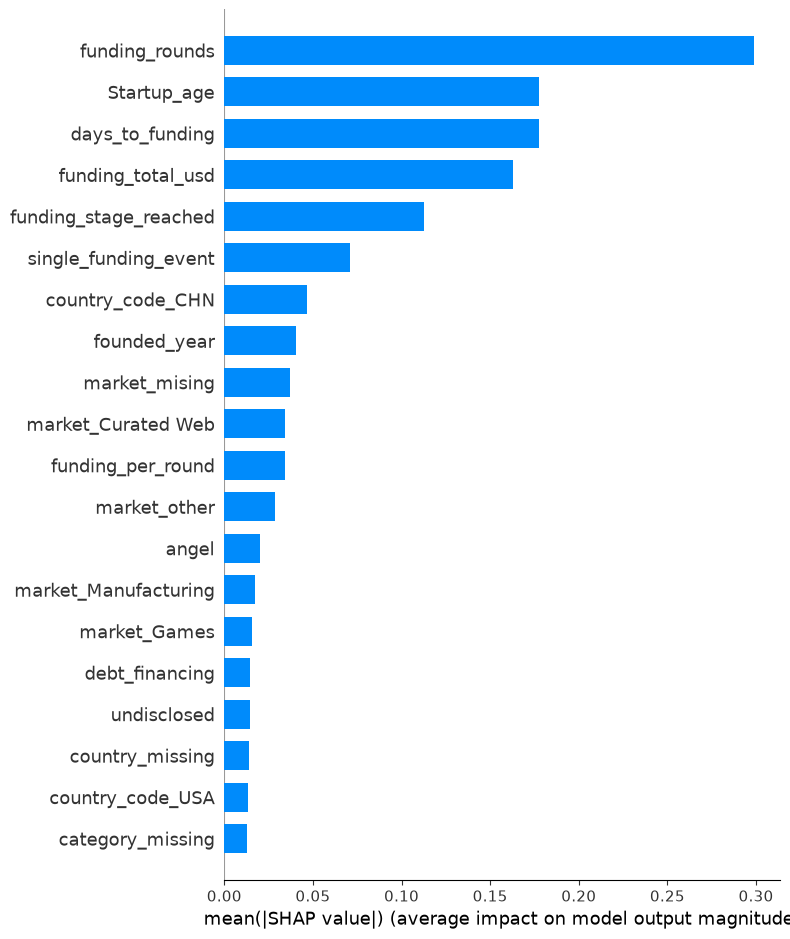

In [24]:
shap.summary_plot(fail_vals,x_test,plot_type="bar") #global feature importance

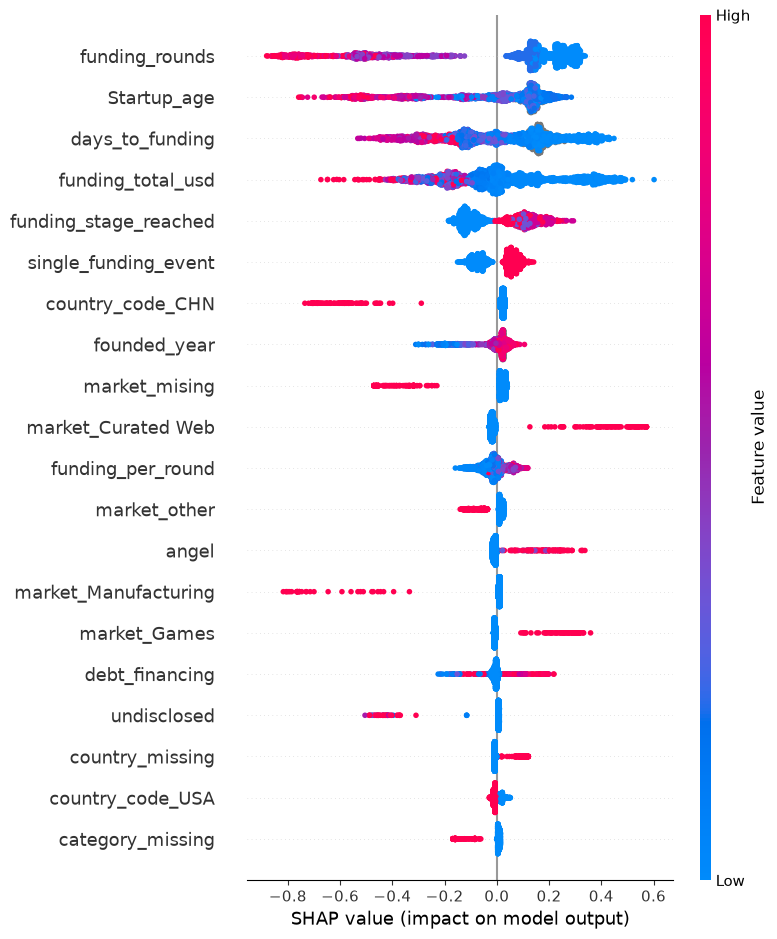

In [25]:
shap.summary_plot(fail_vals, x_test)

### SHAP findings on LightGBM v2

- With `funding_duration_days` removed, the top feature is `funding_rounds` (mean |SHAP| ≈ 0.30, about 1.7x the runner-up, down from 2.7x in v1). 